# Phase 1 — Data Acquisition
## Air Quality Intelligence Platform

This notebook loads and inspects two data sources:
1. **UCI Air Quality Dataset** — 9,357 hourly sensor readings from an Italian city (2004–2005)
2. **OpenAQ API v3** — Live multi-city air quality data from monitoring stations across Europe

Together these form the raw foundation for our machine learning pipeline.

In [3]:
# ── Standard library ──────────────────────────────────────────────
import os          # File system operations and environment variables
import time        # Pausing between API calls to respect rate limits
import warnings    # Suppress non-critical warning messages

# ── Third-party libraries ─────────────────────────────────────────
import pandas as pd          # DataFrames — our main data structure
import numpy as np           # Numerical operations (np.nan for missing values)
import requests              # HTTP requests to the OpenAQ REST API
import matplotlib.pyplot as plt   # Plotting
import seaborn as sns             # Statistical visualisations (built on matplotlib)
from dotenv import load_dotenv    # Reads our .env file to load the API key safely

# ── Settings ──────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
# Suppresses non-critical warnings so the notebook output stays clean

pd.set_option("display.max_columns", 20)
# Show up to 20 columns before pandas starts hiding them with "..."

pd.set_option("display.float_format", "{:.3f}".format)
# Format all floating-point numbers to 3 decimal places in display

plt.style.use("seaborn-v0_8-whitegrid")
# Apply a clean, professional plot style. "seaborn-v0_8-whitegrid" is
# the correct name in newer matplotlib versions (previously "seaborn-whitegrid")

print("All libraries imported successfully ✓")
print(f"pandas  version: {pd.__version__}")
print(f"numpy   version: {np.__version__}")
print(f"requests version: {requests.__version__}")

All libraries imported successfully ✓
pandas  version: 3.0.2
numpy   version: 2.4.4
requests version: 2.33.1


In [4]:
# load_dotenv() searches for a .env file starting from the current directory
# and going up the folder tree. Because the notebook is in notebooks/ and
# the .env file is in the project root (one level up), we pass the explicit path.
load_dotenv(dotenv_path="../.env")

# os.getenv() reads an environment variable by name.
# If the variable doesn't exist, it returns None.
OPENAQ_API_KEY = os.getenv("OPENAQ_API_KEY")

# Validate that the key was found before we proceed.
# assert condition, message — raises AssertionError with the message if False.
assert OPENAQ_API_KEY, (
    "OPENAQ_API_KEY not found!\n"
    "Make sure your .env file is in the project ROOT folder (not inside notebooks/).\n"
    "The file should contain exactly: OPENAQ_API_KEY=your_key_here"
)

# We print only the first 8 characters as confirmation — never print the full key.
print(f"API key loaded successfully ✓  (starts with: {OPENAQ_API_KEY[:8]}...)")

API key loaded successfully ✓  (starts with: ce8735e2...)


---
## Part 1 — UCI Air Quality Dataset

The UCI Air Quality dataset contains 9,357 hourly recordings from a gas multisensor 
device deployed in a polluted area of an Italian city between March 2004 and April 2005.

**Key sensors recorded:**
- CO, NMHC, Benzene, NOx, NO₂, Ozone (actual concentrations + metal oxide sensor responses)
- Temperature (T), Relative Humidity (RH), Absolute Humidity (AH)

**Known quirks to handle:**
- Separator is `;` not `,`
- Decimal separator is `,` not `.` (European format)
- Missing values are encoded as `-200` (hardware sentinel value)
- Two completely empty trailing columns exist in the Excel version

In [5]:
# Path is relative to the notebook location (notebooks/).
# "../" goes up one level to the project root, then into data/raw/
UCI_PATH = "../data/raw/AirQualityUCI.xlsx"

# ── Read the Excel file ───────────────────────────────────────────
# pd.read_excel() loads an .xlsx file directly into a DataFrame.
# A DataFrame is pandas' core structure: a 2D table with labelled
# rows (index) and columns, similar to a spreadsheet.
df_uci_raw = pd.read_excel(UCI_PATH)

print(f"Raw shape: {df_uci_raw.shape}")
# .shape returns (number_of_rows, number_of_columns) as a tuple

print(f"Columns: {df_uci_raw.columns.tolist()}")
# .columns gives the column labels; .tolist() converts to a plain Python list

df_uci_raw.head(3)
# .head(n) shows the first n rows. In a notebook, the last expression
# in a cell is automatically displayed as a formatted table — no print() needed.

Raw shape: (9357, 15)
Columns: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.600,1360.000,150,11.882,1045.500,166.000,1056.250,113.000,1692.000,1267.500,13.600,48.875,0.758
1,2004-03-10,19:00:00,2.000,1292.250,112,9.397,954.750,103.000,1173.750,92.000,1558.750,972.250,13.300,47.700,0.725
2,2004-03-10,20:00:00,2.200,1402.000,88,8.998,939.250,131.000,1140.000,114.000,1554.500,1074.000,11.900,53.975,0.750


In [6]:
# ── Step 1: Drop completely empty columns ─────────────────────────
# The Excel export adds two unnamed, fully-empty trailing columns.
# dropna(axis=1, how="all") drops columns where EVERY value is NaN.
# axis=1 means "work on columns"; axis=0 means "work on rows".
df_uci = df_uci_raw.dropna(axis=1, how="all").copy()
# .copy() creates a true independent copy, preventing the
# "SettingWithCopyWarning" pandas raises when you modify a slice.

# ── Step 2: Drop completely empty rows ────────────────────────────
# Same logic for rows — the Excel file often has blank rows at the bottom.
df_uci = df_uci.dropna(axis=0, how="all")

# ── Step 3: Replace -200 sentinel with NaN ────────────────────────
# The sensor hardware used -200 as "no reading available".
# np.nan is the standard "missing value" in pandas/numpy.
# Replacing it lets pandas handle missing data correctly in
# statistics (.mean() skips NaN) and models (require explicit handling).
df_uci = df_uci.replace(-200, np.nan)

# ── Step 4: Fix numeric columns ───────────────────────────────────
# The Excel uses European decimal notation (comma as decimal point).
# pandas loaded all sensor columns as strings (dtype=object).
# We must convert them to float (decimal numbers) explicitly.

# These are all columns EXCEPT Date, Time (which we handle separately)
sensor_cols = [c for c in df_uci.columns if c not in ["Date", "Time"]]
# List comprehension: creates a list by filtering — reads as
# "for each column name c in df_uci.columns, include it IF it's not Date/Time"

for col in sensor_cols:
    # pd.to_numeric() converts a column to numbers.
    # errors="coerce": if a value can't be converted, replace with NaN
    # (rather than crashing). This cleanly handles any stray text.
    df_uci[col] = pd.to_numeric(df_uci[col], errors="coerce")

# ── Step 5: Build a proper DateTime column ────────────────────────
# The dataset stores date and time in separate columns.
# We combine them into a single datetime column for time-series work.
# pd.to_datetime() parses the combined string into a datetime object —
# a Python object that understands time ordering, arithmetic, and formatting.
df_uci["DateTime"] = pd.to_datetime(
    df_uci["Date"].astype(str) + " " + df_uci["Time"].astype(str),
    dayfirst=True,     # European date format: day/month/year (not month/day/year)
    errors="coerce"    # Replace unparseable values with NaT (Not a Time)
)

# ── Step 6: Drop the now-redundant separate Date and Time columns ──
df_uci = df_uci.drop(columns=["Date", "Time"], errors="ignore")

# ── Step 7: Sort chronologically and reset the index ──────────────
# sort_values() reorders rows. By DateTime, ascending (oldest first).
# reset_index(drop=True) resets row numbers to 0,1,2,... after sorting.
# drop=True prevents the old index from being added as a new column.
df_uci = df_uci.sort_values("DateTime").reset_index(drop=True)

print(f"Cleaned shape:  {df_uci.shape}")
print(f"\nData types after cleaning:")
print(df_uci.dtypes)

Cleaned shape:  (9357, 14)

Data types after cleaning:
CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
DateTime         datetime64[us]
dtype: object


In [7]:
# Preview the first 5 rows of cleaned data
print("First 5 rows:")
df_uci.head()

First 5 rows:


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
0,1.600,1143.000,106.000,6.292,825.250,96.000,985.500,86.000,1477.250,978.250,11.950,61.625,0.859,2004-01-04 00:00:00
1,1.200,1043.750,100.000,5.121,769.500,85.000,1031.250,70.000,1424.750,944.250,11.500,63.875,0.865,2004-01-04 01:00:00
2,1.100,1034.000,71.000,4.087,715.500,50.000,1085.000,55.000,1405.000,891.250,10.675,67.225,0.863,2004-01-04 02:00:00
3,0.900,956.250,72.000,4.046,713.250,NaN,1098.500,NaN,1421.500,848.750,8.975,73.100,0.839,2004-01-04 03:00:00
4,0.700,909.250,44.000,2.434,615.000,57.000,1237.000,49.000,1321.500,789.500,10.225,66.575,0.830,2004-01-04 04:00:00


In [8]:
# .describe() computes summary statistics for all numeric columns:
# count (non-null entries), mean, std (standard deviation),
# min, 25th percentile, median (50th), 75th percentile, max.
# .T transposes (flips rows/columns) so each column becomes a row —
# much easier to read when there are many columns.
print("Summary statistics (transposed for readability):")
df_uci.describe().T.round(2)

Summary statistics (transposed for readability):


,count,mean,min,25%,50%,75%,max,std
CO(GT),7674.000,2.153,0.100,1.100,1.800,2.900,11.900,1.453
PT08.S1(CO),8991.000,1099.708,647.250,936.750,1063.000,1231.250,2039.750,217.085
NMHC(GT),914.000,218.812,7.000,67.000,150.000,297.000,1189.000,204.460
C6H6(GT),8991.000,10.083,0.149,4.437,8.240,13.988,63.741,7.450
PT08.S2(NMHC),8991.000,939.029,383.250,734.375,909.000,1116.250,2214.000,266.829
NOx(GT),7718.000,246.881,2.000,98.000,179.800,326.000,1479.000,212.971
PT08.S3(NOx),8991.000,835.371,322.000,657.875,805.500,969.250,2682.750,256.815
NO2(GT),7715.000,113.076,2.000,78.000,109.000,142.000,339.700,48.359
PT08.S4(NO2),8991.000,1456.143,551.000,1226.625,1462.750,1673.500,2775.000,346.205
PT08.S5(O3),8991.000,1022.781,221.000,731.375,963.250,1273.375,2522.750,398.481


Missing value percentages per column:
NMHC(GT)        90.230
DateTime        61.560
CO(GT)          17.990
NO2(GT)         17.550
NOx(GT)         17.520
PT08.S1(CO)      3.910
PT08.S2(NMHC)    3.910
C6H6(GT)         3.910
PT08.S4(NO2)     3.910
PT08.S3(NOx)     3.910
PT08.S5(O3)      3.910
T                3.910
RH               3.910
AH               3.910
dtype: float64


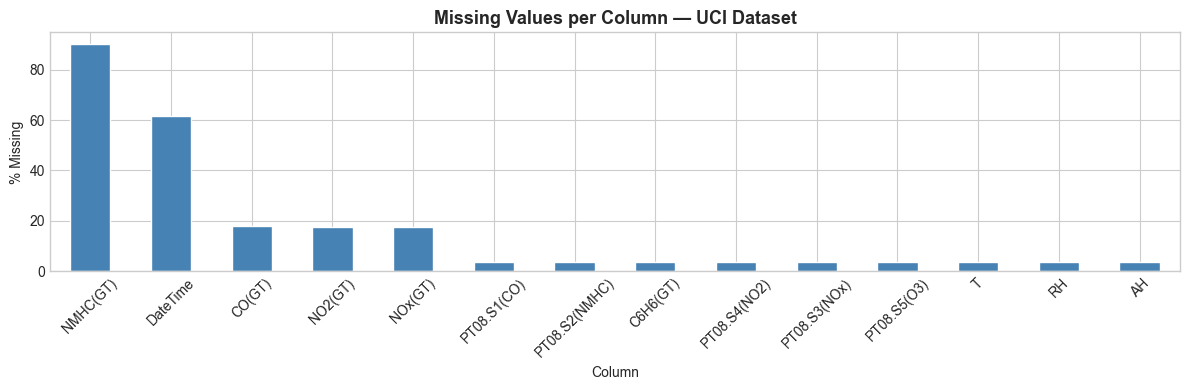

Chart saved to outputs/01_missing_values_uci.png ✓


In [9]:
# Calculate the percentage of missing values per column
missing_pct = (df_uci.isnull().sum() / len(df_uci) * 100).sort_values(ascending=False)
# .isnull() returns a boolean DataFrame (True=missing, False=present)
# .sum() counts True values per column (True=1, False=0)
# Dividing by len(df_uci) (total rows) and multiplying by 100 gives percentage

print("Missing value percentages per column:")
print(missing_pct.round(2))

# ── Plot missing values as a bar chart ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
# plt.subplots() creates a Figure (the whole canvas) and an Axes (one plot area).
# figsize=(width_inches, height_inches). We store both in fig and ax.

missing_pct[missing_pct > 0].plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
# We filter to only show columns that have at least some missing data.
# kind="bar" makes a vertical bar chart. ax=ax places it on our axes object.

ax.set_title("Missing Values per Column — UCI Dataset", fontsize=13, fontweight="bold")
ax.set_xlabel("Column")
ax.set_ylabel("% Missing")
ax.tick_params(axis="x", rotation=45)
# Rotate x-axis labels 45 degrees so column names don't overlap

plt.tight_layout()
# tight_layout() automatically adjusts spacing so labels don't get cut off

plt.savefig("../outputs/01_missing_values_uci.png", dpi=150, bbox_inches="tight")
# Save the chart to disk. dpi=150 means higher resolution.
# bbox_inches="tight" prevents axis labels from being clipped at the edge.

plt.show()
print("Chart saved to outputs/01_missing_values_uci.png ✓")

In [10]:
# Make sure the outputs folder exists before saving charts into it
os.makedirs("../outputs", exist_ok=True)
# exist_ok=True: if the folder already exists, don't raise an error

# Save the cleaned UCI DataFrame to CSV
uci_save_path = "../data/raw/uci_air_quality_cleaned.csv"
df_uci.to_csv(uci_save_path, index=False, encoding="utf-8")
# index=False: don't write the row numbers (0,1,2...) as a column in the file

print(f"UCI cleaned dataset saved ✓")
print(f"  Path:  {uci_save_path}")
print(f"  Shape: {df_uci.shape}")
print(f"  Date range: {df_uci['DateTime'].min()} → {df_uci['DateTime'].max()}")

UCI cleaned dataset saved ✓
  Path:  ../data/raw/uci_air_quality_cleaned.csv
  Shape: (9357, 14)
  Date range: 2004-01-04 00:00:00 → 2005-12-03 23:00:00


---
## Part 2 — OpenAQ API v3 (Live Multi-City Data)

OpenAQ aggregates air quality data from **thousands of government monitoring 
stations** across the world, updated continuously.

**Why this is "big data":** We're not working with a static file — we're 
programmatically pulling from a live API that tracks hundreds of thousands 
of sensor readings across dozens of countries. The architecture we're building 
here scales naturally to millions of rows.

**API v3 key facts:**
- Base URL: `https://api.openaq.org/v3`
- Authentication: `X-API-Key` header
- Country filter: use the `iso` parameter (2-letter code e.g. `"IT"`)
- `countries_id` is a *different* parameter — it takes **integer IDs**, not strings

In [11]:
BASE_URL = "https://api.openaq.org/v3"

# The headers dictionary is sent with every API request.
# "X-API-Key" is the exact header name OpenAQ v3 requires.
HEADERS = {"X-API-Key": OPENAQ_API_KEY}

def fetch_locations_by_iso(iso_code: str, limit: int = 100) -> list:
    """
    Fetches monitoring station locations for a given country.

    The critical fix vs. the original code:
    - Use `iso` parameter (2-letter string like "IT") NOT `countries_id`
    - `countries_id` expects an integer database ID — completely different thing

    Args:
        iso_code: 2-letter ISO 3166-1 country code (e.g. "IT", "FR", "DE")
        limit:    Maximum results to return per page (OpenAQ max is 1000)

    Returns:
        List of location dictionaries from the API response
    """
    params = {
        "iso":   iso_code,   # ← CORRECT parameter for string country codes
        "limit": limit,
        "page":  1
    }

    response = requests.get(
        f"{BASE_URL}/locations",
        headers=HEADERS,
        params=params,
        timeout=15           # Wait max 15 seconds before giving up
        # timeout prevents the script hanging forever if the API is slow
    )

    if response.status_code == 200:
        return response.json().get("results", [])
    else:
        # Print the full error body — this tells us exactly what's wrong
        print(f"  Error {response.status_code} for {iso_code}: {response.text[:200]}")
        return []


# ── Fetch locations for Italy, France, Germany ────────────────────
COUNTRIES = ["IT", "FR", "DE"]
all_locations = []

for country in COUNTRIES:
    print(f"Fetching locations for: {country}")
    results = fetch_locations_by_iso(country, limit=100)
    
    for loc in results:
        # Extract the fields we need from each location dictionary.
        # The v3 API nests country info inside a "country" sub-dict.
        # The coordinates are inside a "coordinates" sub-dict.
        coords  = loc.get("coordinates") or {}
        country_info = loc.get("country") or {}

        # Extract the list of sensors at this location.
        # Each sensor has a "parameter" sub-dict with the pollutant name.
        sensors = loc.get("sensors", [])
        params_available = [
            s.get("parameter", {}).get("name", "")
            for s in sensors
        ]
        # List comprehension: for each sensor s, get its parameter name

        all_locations.append({
            "location_id":         loc.get("id"),
            "location_name":       loc.get("name"),
            "country_code":        country_info.get("code", country),
            "city":                loc.get("locality"),
            "latitude":            coords.get("latitude"),
            "longitude":           coords.get("longitude"),
            "is_mobile":           loc.get("isMobile", False),
            "is_monitor":          loc.get("isMonitor", False),
            "parameters_available": ", ".join(params_available),
            # ", ".join(...) converts a list ["no2","pm25"] to a string "no2, pm25"
        })

    print(f"  → {len(results)} locations found")
    time.sleep(0.5)   # Pause 0.5s between country requests

# Convert list of dicts to DataFrame
df_locations = pd.DataFrame(all_locations)
print(f"\nTotal locations: {len(df_locations)}")
df_locations.head(10)

Fetching locations for: IT
  → 100 locations found
Fetching locations for: FR
  → 100 locations found
Fetching locations for: DE
  → 100 locations found

Total locations: 300


,location_id,location_name,country_code,city,latitude,longitude,is_mobile,is_monitor,parameters_available
0,5369,Tarquinia,IT,NaN,42.240,11.766,False,True,"no2, pm10, so2"
1,6409,Aprilia 2,IT,Latina,41.595,12.654,False,True,"no, no2, nox, o3, pm10, so2"
2,6875,LUGAGNANO,IT,NaN,44.824,9.830,False,True,"no2, o3, pm10"
3,7155,CENO,IT,NaN,45.054,9.727,False,True,"co, pm10"
4,7156,GERBIDO,IT,NaN,45.056,9.748,False,True,"co, no2, pm10"
5,7157,MALCANTONE,IT,NaN,44.891,10.400,False,True,"no2, pm10"
6,7158,PARADIGNA,IT,NaN,44.841,10.345,False,True,"no2, pm10"
7,7159,BOGOLESE,IT,NaN,44.829,10.392,False,True,"no2, pm10"
8,7234,MONTEBELLO,IT,NaN,44.787,10.336,False,True,"co, no2, pm10"
9,7235,DE AMICIS,IT,NaN,44.355,11.721,False,True,"co, no2, pm10"


In [12]:
print("Locations by country:")
print(df_locations["country_code"].value_counts())
# value_counts() counts how many rows have each unique value —
# here it tells us how many stations we found per country

print(f"\nFixed stations (not mobile): {(~df_locations['is_mobile']).sum()}")
# ~ is the bitwise NOT operator — flips True/False
# .sum() counts True values (True=1, False=0)

print(f"Reference monitors: {df_locations['is_monitor'].sum()}")

# Show which pollutants are available
print("\nSample of parameters available at stations:")
print(df_locations["parameters_available"].head(10))

Locations by country:
country_code
IT    100
FR    100
DE    100
Name: count, dtype: int64

Fixed stations (not mobile): 300
Reference monitors: 300

Sample of parameters available at stations:
0                 no2, pm10, so2
1    no, no2, nox, o3, pm10, so2
2                  no2, o3, pm10
3                       co, pm10
4                  co, no2, pm10
5                      no2, pm10
6                      no2, pm10
7                      no2, pm10
8                  co, no2, pm10
9                  co, no2, pm10
Name: parameters_available, dtype: str


In [13]:
locations_path = "../data/raw/openaq_locations.csv"
df_locations.to_csv(locations_path, index=False)
print(f"Locations saved to {locations_path} ✓  ({len(df_locations)} rows)")

Locations saved to ../data/raw/openaq_locations.csv ✓  (300 rows)


In [14]:
from datetime import datetime, timedelta, timezone

def fetch_sensor_measurements(sensor_id: int, days_back: int = 30) -> list:
    """
    Fetches hourly aggregated NO2 measurements for a single sensor.

    We use the /sensors/{id}/hours endpoint which returns
    pre-aggregated hourly averages — exactly what we need for
    time-series modelling. Much cleaner than raw measurements.

    Args:
        sensor_id: Integer sensor ID from the locations response
        days_back: How many days of history to retrieve

    Returns:
        List of measurement dicts with datetime and value
    """
    date_to   = datetime.now(timezone.utc)
    date_from = date_to - timedelta(days=days_back)

    # ISO 8601 format with Z suffix — required by OpenAQ v3
    params = {
        "datetime_from": date_from.strftime("%Y-%m-%dT%H:%M:%SZ"),
        "datetime_to":   date_to.strftime("%Y-%m-%dT%H:%M:%SZ"),
        "limit": 1000,
        "page":  1
    }

    response = requests.get(
        f"{BASE_URL}/sensors/{sensor_id}/hours",
        headers=HEADERS,
        params=params,
        timeout=15
    )

    if response.status_code == 200:
        return response.json().get("results", [])
    return []


# ── Find sensors measuring NO2 at fixed (non-mobile) stations ─────
# We only want fixed reference stations for reliable data
fixed_locations = df_locations[
    (~df_locations["is_mobile"]) &                          # not mobile
    (df_locations["parameters_available"].str.contains(     # has no2 data
        "no2", case=False, na=False))
]
# DataFrame filtering: df[condition] returns only rows where condition is True.
# & is the bitwise AND for combining multiple conditions in pandas.
# .str.contains() checks if a string column contains a substring.
# case=False means case-insensitive. na=False means treat NaN as False.

print(f"Fixed stations with NO2 sensors: {len(fixed_locations)}")

# Collect sensor IDs for NO2 from the raw locations data
# We need to go back to the raw API response for sensor IDs.
# Let's re-fetch a small batch with sensor detail.

no2_measurements = []
stations_fetched = 0

for _, row in fixed_locations.head(15).iterrows():
    # iterrows() loops over DataFrame rows as (index, Series) pairs.
    # We use _ for the index because we don't need it.
    loc_id = row["location_id"]
    
    # Get sensors for this location
    sensor_resp = requests.get(
        f"{BASE_URL}/locations/{int(loc_id)}/sensors",
        headers=HEADERS,
        timeout=15
    )
    
    if sensor_resp.status_code != 200:
        time.sleep(0.3)
        continue
    
    sensors = sensor_resp.json().get("results", [])
    
    for sensor in sensors:
        param_name = sensor.get("parameter", {}).get("name", "").lower()
        if param_name != "no2":
            continue
        
        sensor_id = sensor.get("id")
        print(f"  Fetching NO2 data: location {loc_id}, sensor {sensor_id}...")
        
        readings = fetch_sensor_measurements(sensor_id, days_back=30)
        
        for r in readings:
            # The hourly endpoint returns period.datetimeTo for the hour end
            period = r.get("period", {})
            dt_info = period.get("datetimeTo", {})
            
            no2_measurements.append({
                "location_id":  loc_id,
                "location_name": row["location_name"],
                "country":       row["country_code"],
                "city":          row["city"],
                "latitude":      row["latitude"],
                "longitude":     row["longitude"],
                "datetime_utc":  dt_info.get("utc"),
                "no2_value":     r.get("value"),
                "unit":          "µg/m³"
            })
        
        stations_fetched += 1
        time.sleep(0.4)
    
    if stations_fetched >= 10:
        # Stop after 10 stations — enough for a solid demo dataset
        break

df_no2 = pd.DataFrame(no2_measurements)
print(f"\nNO2 measurements collected: {len(df_no2)} rows across {stations_fetched} stations")
df_no2.head()

Fixed stations with NO2 sensors: 260
  Fetching NO2 data: location 5369, sensor 13965...
  Fetching NO2 data: location 6409, sensor 21873...
  Fetching NO2 data: location 6875, sensor 19774...
  Fetching NO2 data: location 7156, sensor 20597...
  Fetching NO2 data: location 7157, sensor 20605...
  Fetching NO2 data: location 7158, sensor 20603...
  Fetching NO2 data: location 7159, sensor 20604...
  Fetching NO2 data: location 7234, sensor 22137...
  Fetching NO2 data: location 7235, sensor 22194...
  Fetching NO2 data: location 7236, sensor 22156...

NO2 measurements collected: 843 rows across 10 stations


,location_id,location_name,country,city,latitude,longitude,datetime_utc,no2_value,unit
0,6409,Aprilia 2,IT,Latina,41.595,12.654,2026-03-11T15:00:00Z,7.000,µg/m³
1,6409,Aprilia 2,IT,Latina,41.595,12.654,2026-03-11T16:00:00Z,7.000,µg/m³
2,6409,Aprilia 2,IT,Latina,41.595,12.654,2026-03-11T17:00:00Z,9.000,µg/m³
3,6409,Aprilia 2,IT,Latina,41.595,12.654,2026-03-11T18:00:00Z,21.000,µg/m³
4,6409,Aprilia 2,IT,Latina,41.595,12.654,2026-03-11T19:00:00Z,39.000,µg/m³


In [15]:
# Convert the datetime string column to a proper pandas datetime
df_no2["datetime_utc"] = pd.to_datetime(df_no2["datetime_utc"], utc=True, errors="coerce")
# utc=True tells pandas these are UTC timestamps — important for correct time arithmetic

# Drop rows where we couldn't parse the datetime or the value is missing
df_no2 = df_no2.dropna(subset=["datetime_utc", "no2_value"])

# Sort chronologically
df_no2 = df_no2.sort_values("datetime_utc").reset_index(drop=True)

print("NO2 measurements summary:")
print(f"  Rows:       {len(df_no2)}")
print(f"  Countries:  {df_no2['country'].unique().tolist()}")
print(f"  Date range: {df_no2['datetime_utc'].min()} → {df_no2['datetime_utc'].max()}")
print(f"\nNO2 value statistics:")
print(df_no2["no2_value"].describe().round(3))

NO2 measurements summary:
  Rows:       843
  Countries:  ['IT']
  Date range: 2026-03-11 15:00:00+00:00 → 2026-04-09 00:00:00+00:00

NO2 value statistics:
count   843.000
mean     16.814
std      11.495
min       1.000
25%       9.000
50%      13.000
75%      20.000
max      82.000
Name: no2_value, dtype: float64


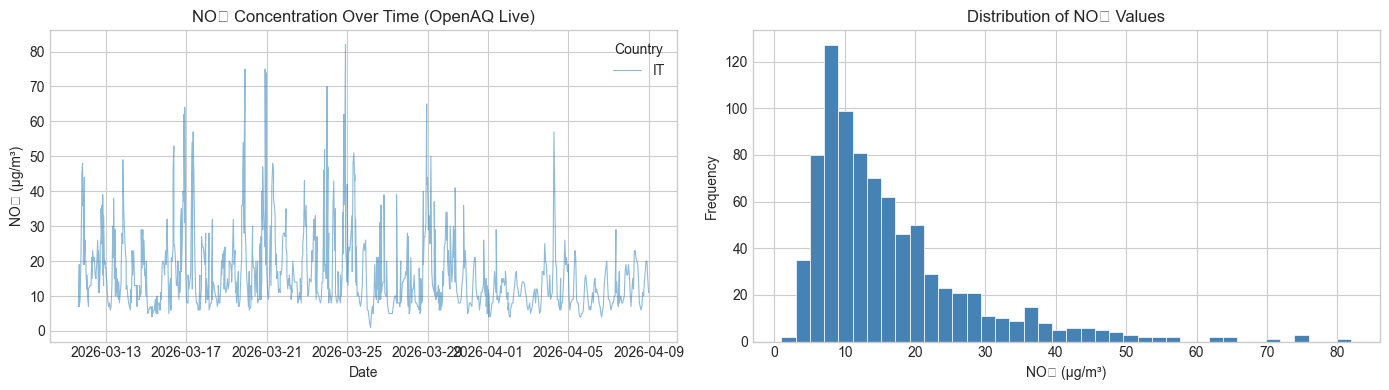

Chart saved ✓


In [16]:
if len(df_no2) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    # Create 1 row, 2 columns of subplots side by side.
    # axes is an array: axes[0] = left plot, axes[1] = right plot.

    # ── Left: NO2 over time per country ───────────────────────────
    for country, group in df_no2.groupby("country"):
        # groupby("country") splits the DataFrame into groups by country.
        # The for loop gives us each group as (group_name, group_DataFrame).
        axes[0].plot(
            group["datetime_utc"],
            group["no2_value"],
            alpha=0.5,      # Transparency (0=invisible, 1=opaque)
            linewidth=0.8,
            label=country
        )
    axes[0].set_title("NO₂ Concentration Over Time (OpenAQ Live)")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("NO₂ (µg/m³)")
    axes[0].legend(title="Country")

    # ── Right: Distribution of NO2 values ─────────────────────────
    axes[1].hist(
        df_no2["no2_value"].dropna(),
        bins=40,              # Number of histogram bars
        color="steelblue",
        edgecolor="white",
        linewidth=0.5
    )
    axes[1].set_title("Distribution of NO₂ Values")
    axes[1].set_xlabel("NO₂ (µg/m³)")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.savefig("../outputs/01_openaq_no2_preview.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Chart saved ✓")
else:
    print("No measurements to plot — check API key and station availability")

In [17]:
# Save the OpenAQ NO2 data
no2_path = "../data/raw/openaq_no2_measurements.csv"
df_no2.to_csv(no2_path, index=False)
print(f"OpenAQ NO2 measurements saved ✓  ({len(df_no2)} rows)")

# ── Final summary ─────────────────────────────────────────────────
print("\n" + "=" * 55)
print("PHASE 1 COMPLETE — Summary")
print("=" * 55)
print(f"  UCI dataset:        {df_uci.shape[0]:,} rows × {df_uci.shape[1]} columns")
print(f"  Date range UCI:     {df_uci['DateTime'].min().date()} → {df_uci['DateTime'].max().date()}")
print(f"  OpenAQ locations:   {len(df_locations)} monitoring stations")
print(f"  OpenAQ NO2 data:    {len(df_no2):,} hourly readings")
print(f"  Countries covered:  {', '.join(df_no2['country'].unique().tolist()) if len(df_no2) else 'N/A'}")
print("=" * 55)
print("\nFiles saved:")
print(f"  data/raw/uci_air_quality_cleaned.csv")
print(f"  data/raw/openaq_locations.csv")
print(f"  data/raw/openaq_no2_measurements.csv")
print(f"  outputs/01_missing_values_uci.png")
print(f"  outputs/01_openaq_no2_preview.png")

OpenAQ NO2 measurements saved ✓  (843 rows)

PHASE 1 COMPLETE — Summary
  UCI dataset:        9,357 rows × 14 columns
  Date range UCI:     2004-01-04 → 2005-12-03
  OpenAQ locations:   300 monitoring stations
  OpenAQ NO2 data:    843 hourly readings
  Countries covered:  IT

Files saved:
  data/raw/uci_air_quality_cleaned.csv
  data/raw/openaq_locations.csv
  data/raw/openaq_no2_measurements.csv
  outputs/01_missing_values_uci.png
  outputs/01_openaq_no2_preview.png
